# BPS5231 AI For Sustainable Building Design - L7

## MNIST: From Logistic Regression to Deep MLP

Affine → Activation blocks and why stacking them matters

Effect of depth (number of hidden layers) and width (neurons per layer)

Training curves, confusion matrix, capacity vs overfitting trade-offs

In [1]:
import random, numpy as np, matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers, regularizers

SEED = 42
random.seed(SEED); np.random.seed(SEED); tf.random.set_seed(SEED)
print("TensorFlow:", tf.__version__)

TensorFlow: 2.19.0


In [2]:
(x_train, y_train), (x_test, y_test) = keras.datasets.mnist.load_data()

x_train = x_train.astype("float32") / 255.0
x_test  = x_test.astype("float32") / 255.0

# Flatten images (MLP)
x_train_flat = x_train.reshape(len(x_train), -1)  # [60000, 784]
x_test_flat  = x_test.reshape(len(x_test), -1)

num_classes = 10
input_dim   = x_train_flat.shape[1]
print("Train:", x_train_flat.shape, " Test:", x_test_flat.shape)

11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 1s 0us/step
Train: (60000, 784)  Test: (10000, 784)


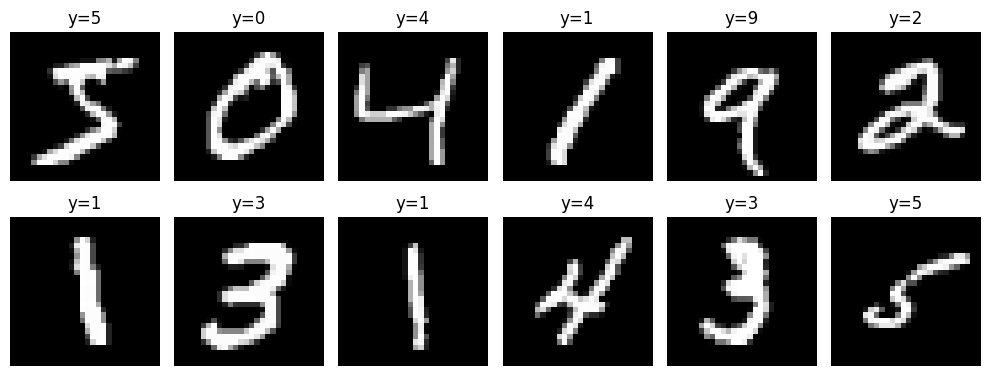

In [3]:
rows, cols = 2, 6
plt.figure(figsize=(10,4))
for i in range(rows*cols):
    plt.subplot(rows, cols, i+1)
    plt.imshow(x_train[i], cmap="gray")
    plt.title(f"y={y_train[i]}")
    plt.axis("off")
plt.tight_layout(); plt.show()

Baseline = Logistic Regression (0 hidden layers)

Affine → Softmax (no nonlinearity in between).

In [4]:
base = keras.Sequential([
    layers.Input(shape=(input_dim,)),
    layers.Dense(num_classes, activation="softmax")
])

base.compile(optimizer=keras.optimizers.SGD(learning_rate=0.1),
             loss="sparse_categorical_crossentropy",
             metrics=["accuracy"])

hist_base = base.fit(x_train_flat, y_train,
                     validation_split=0.1, epochs=10, batch_size=128, verbose=0)

base_eval = base.evaluate(x_test_flat, y_test, verbose=0)
print("Baseline (0 hidden layers) — Test Acc:", f"{base_eval[1]:.4f}")

Baseline (0 hidden layers) — Test Acc: 0.9218


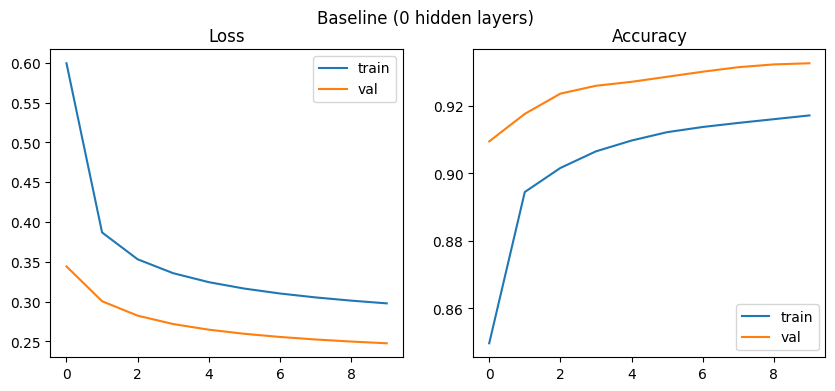

In [5]:
def plot_history(history, title="Training curves"):
    h = history.history
    fig, ax = plt.subplots(1,2, figsize=(10,4))
    ax[0].plot(h["loss"]); ax[0].plot(h["val_loss"]);
    ax[0].set_title("Loss"); ax[0].legend(["train","val"])
    ax[1].plot(h["accuracy"]); ax[1].plot(h["val_accuracy"]);
    ax[1].set_title("Accuracy"); ax[1].legend(["train","val"])
    fig.suptitle(title); plt.show()

plot_history(hist_base, "Baseline (0 hidden layers)")

Configurable MLP (students edit the knobs)

Change NUM_LAYERS, HIDDEN_UNITS, ACTIVATION, DROPOUT, L2_WEIGHT, EPOCHS, BATCH_SIZE.

In [6]:
from tensorflow import keras
from tensorflow.keras import layers

def make_mlp(input_dim, num_layers, hidden_units):
    model = keras.Sequential()
    model.add(layers.Input(shape=(input_dim,)))
    for _ in range(num_layers):
        model.add(layers.Dense(hidden_units, activation="relu"))
    model.add(layers.Dense(num_classes, activation="softmax"))
    return model

# === STUDENT KNOBS (EDIT ONLY THESE TWO) ===
NUM_LAYERS   = 2      # try 0,1,2,3,4
HIDDEN_UNITS = 128    # try 32,64,128,256,512

# Build, train, evaluate
mlp = make_mlp(input_dim, NUM_LAYERS, HIDDEN_UNITS)
mlp.compile(optimizer=keras.optimizers.Adam(1e-3),
            loss="sparse_categorical_crossentropy",
            metrics=["accuracy"])

callbacks=[keras.callbacks.EarlyStopping(patience=3, restore_best_weights=True, monitor="val_accuracy")]
hist_mlp = mlp.fit(x_train_flat, y_train,
                   validation_split=0.1,
                   epochs=10, batch_size=128,
                   callbacks=callbacks, verbose=0)

test_loss, test_acc = mlp.evaluate(x_test_flat, y_test, verbose=0)
print(f"Test Accuracy: {test_acc:.4f}  | layers={NUM_LAYERS}, units={HIDDEN_UNITS}")

Test Accuracy: 0.9759  | layers=2, units=128


In [7]:
print("Model Summary:")
mlp.summary()

print("\nLayer-by-layer details:")
for i, layer in enumerate(mlp.layers):
    conf = getattr(layer, "get_config", lambda: {})()
    name = conf.get("name", layer.name)
    act  = conf.get("activation", "—")
    units = conf.get("units", "—")
    print(f"{i:>2}: {name:20s} | type={layer.__class__.__name__:12s} | units={units} | activation={act}")

print(f"\nTotal parameters: {mlp.count_params():,}")

Model Summary:


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_1 (Dense)                 │ (None, 128)            │       100,480 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 128)            │        16,512 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 354,848 (1.35 MB)

 Trainable params: 118,282 (462.04 KB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 236,566 (924.09 KB)


Layer-by-layer details:
 0: dense_1              | type=Dense        | units=128 | activation=relu
 1: dense_2              | type=Dense        | units=128 | activation=relu
 2: dense_3              | type=Dense        | units=10 | activation=softmax

Total parameters: 118,282


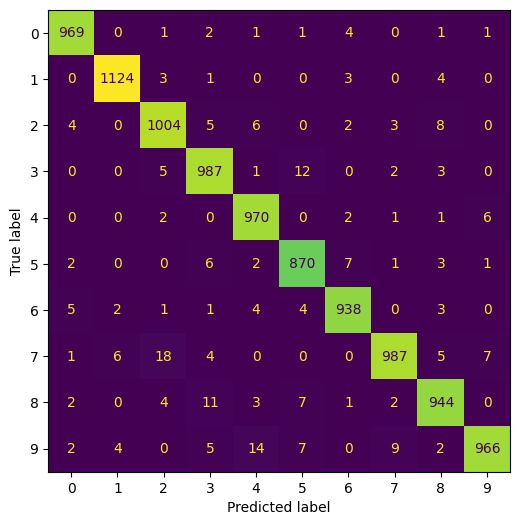

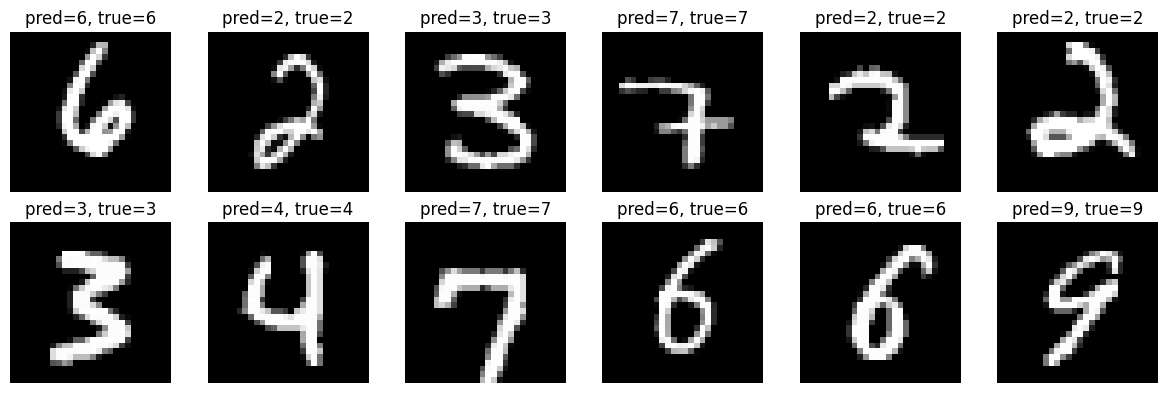

In [8]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

y_prob = mlp.predict(x_test_flat, verbose=0)
y_pred = y_prob.argmax(axis=1)

cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(cm)
fig, ax = plt.subplots(figsize=(6,6))
disp.plot(ax=ax, colorbar=False)
plt.show()

# Show random predictions
idx = np.random.choice(len(x_test), 12, replace=False)
plt.figure(figsize=(12,4))
for i, j in enumerate(idx):
    plt.subplot(2,6,i+1)
    plt.imshow(x_test[j], cmap="gray")
    plt.title(f"pred={y_pred[j]}, true={y_test[j]}")
    plt.axis("off")
plt.tight_layout(); plt.show()

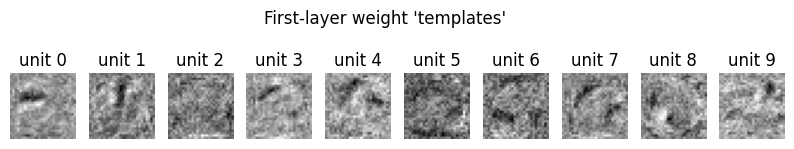

In [9]:
# Works when NUM_LAYERS >= 1
if len([l for l in mlp.layers if isinstance(l, layers.Dense)]) >= 2:
    W = mlp.layers[0].get_weights()[0]  # [784, hidden_units]
    n = min(10, W.shape[1])
    plt.figure(figsize=(10,2))
    for i in range(n):
        plt.subplot(1,n,i+1)
        plt.imshow(W[:,i].reshape(28,28), cmap="gray")
        plt.axis("off"); plt.title(f"unit {i}")
    plt.suptitle("First-layer weight 'templates'"); plt.show()
else:
    print("Add at least 1 hidden layer to visualize weights.")

## Person or Not-Person

Upload → Predict (PERSON vs NOT-PERSON) → Visualize Hidden Layers (Feature Maps + Grad-CAM)

Model: tf.keras.applications.ResNet50V2 (ImageNet pretrained).

You’ll only upload an image — o model tweaking needed.

In [10]:
import numpy as np, matplotlib.pyplot as plt, tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
from tensorflow.keras.applications import resnet_v2
from tensorflow.keras.applications.imagenet_utils import decode_predictions
from PIL import Image
from io import BytesIO

tf.random.set_seed(42)
print("TensorFlow:", tf.__version__)

TensorFlow: 2.19.0


In [11]:
# Pretrained classifier (includes top softmax)
model = resnet_v2.ResNet50V2(weights="imagenet", include_top=True)

# A small set of keywords to flag human categories among ImageNet labels.
# (ImageNet has many person-like subclasses; this covers common ones.)
PERSON_KEYWORDS = {
    "person","man","woman","boy","girl","bridegroom","groom","bride",
    "diver","scuba diver","ballplayer","basketball player","football","runner",
    "dancer","mime","clown","cowboy","barber","singer","violinist","swimmer",
    "skier","surfer","jockey","lifeguard","nurse","police","firefighter","judge",
    "doctor","artist","photographer","bartender","butcher"
}

def is_person_from_topk(decoded_topk, keywords=PERSON_KEYWORDS):
    labels = [name.lower() for (_, name, _) in decoded_topk]
    joined = " | ".join(labels)
    return any(k in joined for k in keywords)

102869336/102869336 ━━━━━━━━━━━━━━━━━━━━ 5s 0us/step


Saving Xueyu.jpeg to Xueyu.jpeg


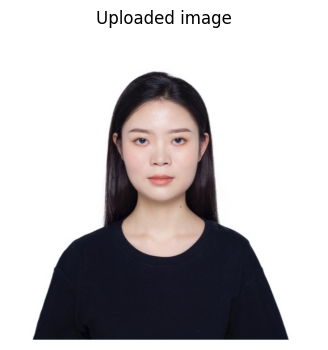

In [17]:
from google.colab import files
uploaded = files.upload()  # pick 1 image (jpg/png)
fname = next(iter(uploaded))  # first filename

# Display original
img = Image.open(BytesIO(uploaded[fname])).convert("RGB")
plt.figure(figsize=(4,4)); plt.imshow(img); plt.axis("off"); plt.title("Uploaded image"); plt.show()

In [18]:
# ResNet50V2 input size is 224x224
img_resized = img.resize((224, 224))
x = np.asarray(img_resized, dtype=np.float32)
x = resnet_v2.preprocess_input(np.expand_dims(x, axis=0))  # [1,224,224,3]

pred = model.predict(x, verbose=0)
top5 = decode_predictions(pred, top=5)[0]

print("Top-5 ImageNet predictions:")
for rank, (cls_id, cls_name, prob) in enumerate(top5, start=1):
    print(f"{rank}. {cls_name:25s}  {prob:.3f}")

person_flag = is_person_from_topk(top5)
print("\n=== FINAL DECISION ===")
print("PERSON" if person_flag else "NOT-PERSON")

Top-5 ImageNet predictions:
1. abaya                      0.969
2. sweatshirt                 0.019
3. jersey                     0.008
4. cloak                      0.001
5. poncho                     0.001

=== FINAL DECISION ===
NOT-PERSON


In [19]:
# Choose a few representative convolutional feature maps (early/mid/late)
layer_names = [
    "conv2_block3_out",  # early textures/edges
    "conv3_block4_out",  # mid-level motifs
    "conv4_block6_out",  # deeper semantics
]
selected_layers = [model.get_layer(n).output for n in layer_names]
feature_model = keras.Model(inputs=model.input, outputs=selected_layers)

# Forward once to get activations
feature_maps = feature_model.predict(x, verbose=0)  # list of tensors
for name, fmap in zip(layer_names, feature_maps):
    print(name, "->", fmap.shape)

conv2_block3_out -> (1, 28, 28, 256)
conv3_block4_out -> (1, 14, 14, 512)
conv4_block6_out -> (1, 7, 7, 1024)


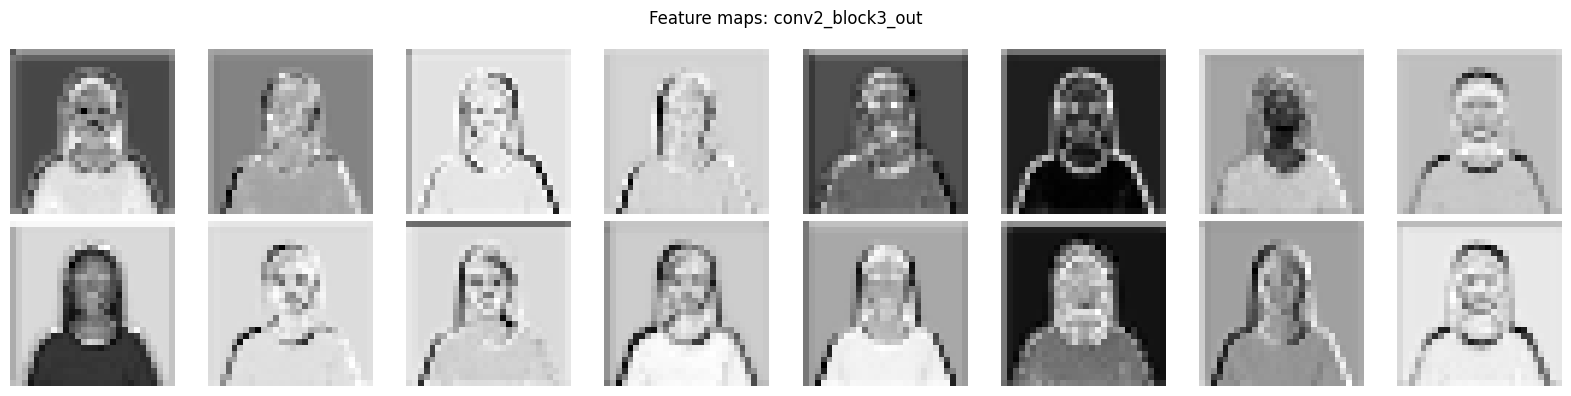

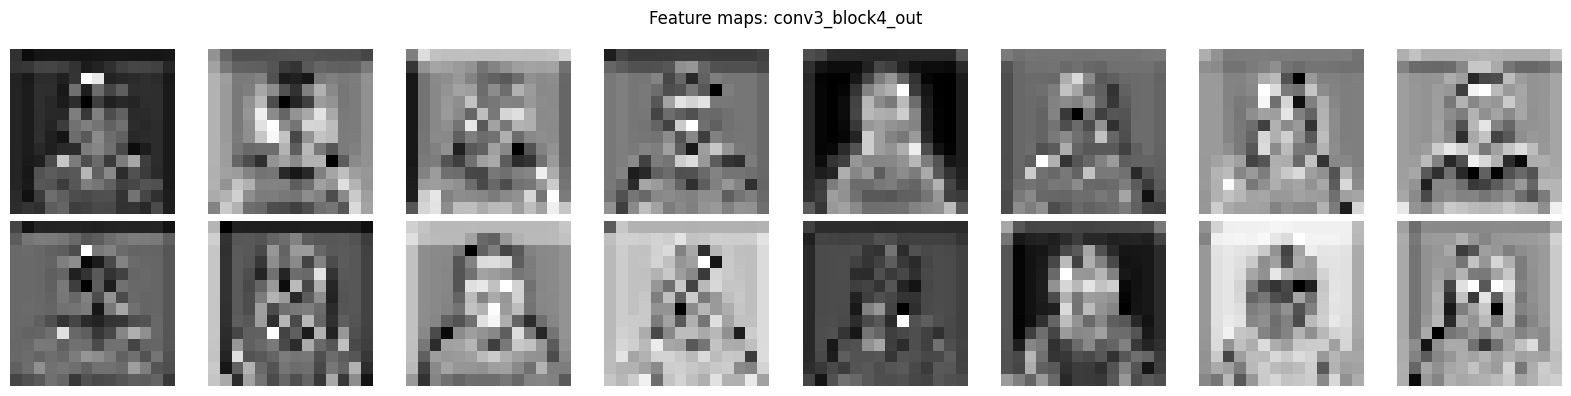

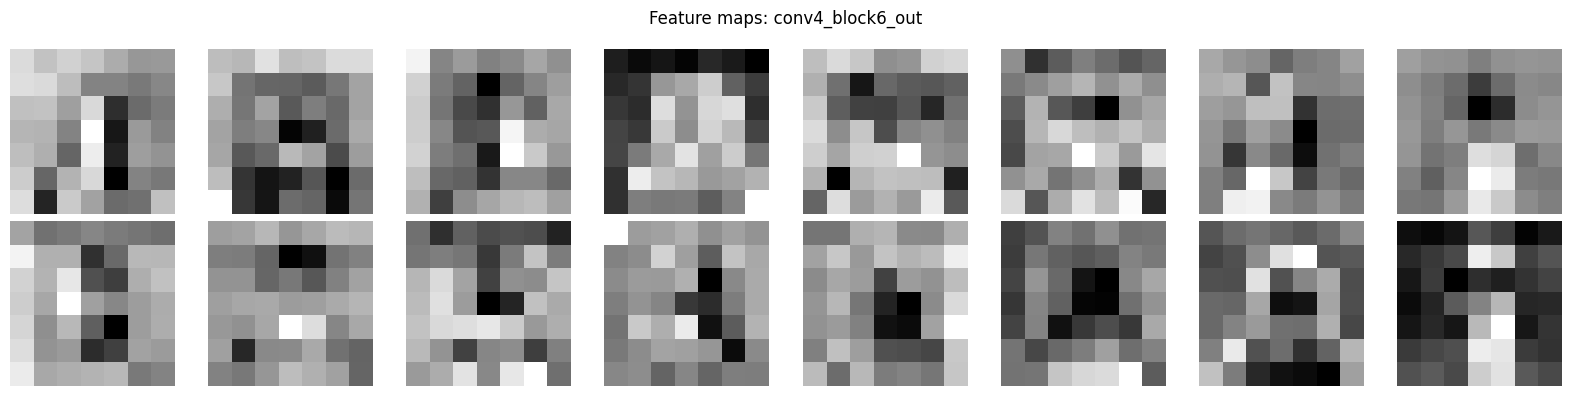

In [20]:
def show_feature_maps(fmap, title, max_channels=16):
    # fmap shape: [1, H, W, C]
    fmap = np.squeeze(fmap, axis=0)
    C = min(max_channels, fmap.shape[-1])
    cols = 8
    rows = int(np.ceil(C/cols))
    plt.figure(figsize=(2*cols, 2*rows))
    for i in range(C):
        plt.subplot(rows, cols, i+1)
        fm = fmap[:, :, i]
        fm = (fm - fm.min()) / (fm.max() - fm.min() + 1e-8)
        plt.imshow(fm, cmap="gray")
        plt.axis("off")
    plt.suptitle(title); plt.tight_layout(); plt.show()

for name, fmap in zip(layer_names, feature_maps):
    show_feature_maps(fmap, f"Feature maps: {name}", max_channels=16)

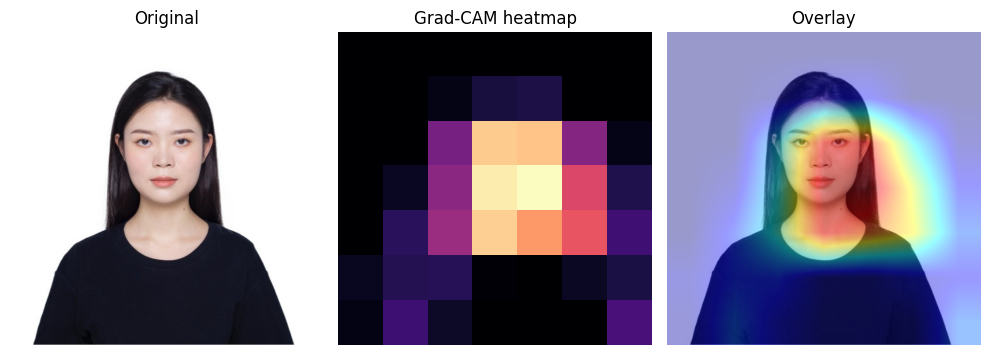

In [21]:
# Grad-CAM: which pixels most drive the top predicted class?
pred_class = np.argmax(pred[0])
last_conv = model.get_layer("conv5_block3_out")  # last conv feature map

# Build a model that outputs both conv features and predictions
grad_model = keras.Model(
    [model.inputs],
    [last_conv.output, model.output]
)

with tf.GradientTape() as tape:
    conv_out, preds = grad_model(x, training=False)
    class_channel = preds[:, pred_class]
    grads = tape.gradient(class_channel, conv_out)

# Global-average-pool the gradients across spatial dims
pooled_grads = tf.reduce_mean(grads, axis=(0, 1, 2))  # [C]
conv_out = conv_out[0]  # [H,W,C]

# Weight the conv feature maps by pooled grads
heatmap = tf.reduce_sum(tf.multiply(conv_out, pooled_grads), axis=-1).numpy()
heatmap = np.maximum(heatmap, 0)
heatmap /= (heatmap.max() + 1e-8)

# Overlay on original image
import cv2
heatmap_img = cv2.resize(heatmap, (img.width, img.height))
heatmap_img = np.uint8(255 * heatmap_img)
heatmap_color = cv2.applyColorMap(heatmap_img, cv2.COLORMAP_JET)

overlay = cv2.addWeighted(np.array(img)[:, :, ::-1], 0.6, heatmap_color, 0.4, 0)  # BGR blending
overlay = overlay[:, :, ::-1]  # back to RGB

plt.figure(figsize=(10,4))
plt.subplot(1,3,1); plt.imshow(img); plt.title("Original"); plt.axis("off")
plt.subplot(1,3,2); plt.imshow(heatmap, cmap="magma"); plt.title("Grad-CAM heatmap"); plt.axis("off")
plt.subplot(1,3,3); plt.imshow(overlay); plt.title("Overlay"); plt.axis("off")
plt.tight_layout(); plt.show()

Early layers pick up colors/edges/textures (like your left-column squares).

Mid/late layers assemble parts → objects → categories (right-side nodes).

Grad-CAM shows where the network looked to make its decision (ideally faces/torso for PERSON).

Limitations: ImageNet labels aren’t a single “person” class; we used a keyword heuristic for a binary PERSON vs NOT-PERSON decision.